# Trabajo Práctico 1 - Librerías de Python

## Análisis de un dataset de fútbol argentino

### Stefano Giacomucci

En este trabajo se realizará un análisis exploratorio de un dataset relacionado con el fútbol argentino.

El objetivo es conocer las características principales de los datos, analizar los valores nulos presentes y realizar diferentes visualizaciones que permitan obtener información relevante.

## Selección y análisis inicial del dataset

### Fuente del dataset

El dataset utilizado fue obtenido de Kaggle:

**Fútbol Argentino**

Fuente: https://www.kaggle.com/datasets/rodrigogastonrubio/futbolargentino

El archivo utilizado para el análisis es `futbolargentino.xlsx`.Especificamente la hoja Worksheet

### ¿Qué contiene el dataset?

El dataset contiene información sobre diferentes jugadores de fútbol y sus características.

Las principales variables son:

- **Jugadores:** nombre del jugador.
- **Posicion:** posición que ocupa dentro del campo.
- **Edad:** edad registrada del jugador.
- **Altura:** altura del jugador.
- **Pie:** pie dominante.
- **Fichado:** fecha relacionada con el fichaje.
- **Equipo Anterior:** club anterior del jugador.
- **Valor de mercado:** valor de mercado registrado.
- **Temporada:** temporada correspondiente al registro.
- **Club:** club actual del jugador.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

archivo = "../data/futbolargentino.xlsx"

excel = pd.ExcelFile(archivo)

excel.sheet_names

df = pd.read_excel(archivo, sheet_name="Worksheet")

df.head()

,Jugadores,Posicion,Edad,Altura,Pie,Fichado,Equipo Anterior,Valor de mercado,Temporada,Club
0,Nicolás Gianni,Centrocampista,25,1.75,derecho,01/07/2000,Inferiores Argentinos Juniors,800000,2008,Argentinos Juniors
1,Maximiliano Sola,Defensa,22,1.8,izquierdo,-,NaN,-,2008,Argentinos Juniors
2,Nicolás Navarro,Portero,23,1.9,derecho,24/07/2010,SSC Nápoles,2000000,2008,Argentinos Juniors
3,Juan Carrera,Portero,27,1.91,derecho,01/01/2005,inactivo,800000,2008,Argentinos Juniors
4,Sebastián Torrico,Portero,28,1.86,derecho,01/01/2009,CD Godoy Cruz Antonio Tomba,250000,2008,Argentinos Juniors


# Analisis inicial

Cantidad de filas y columnas

In [7]:
df.shape

(12092, 10)

Nombres de columnas

In [8]:
df.columns

Index(['Jugadores', 'Posicion', 'Edad', 'Altura', 'Pie', 'Fichado',
       'Equipo Anterior', 'Valor de mercado', 'Temporada', 'Club'],
      dtype='str')

Información general

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12092 entries, 0 to 12091
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Jugadores         12092 non-null  str   
 1   Posicion          12092 non-null  str   
 2   Edad              12092 non-null  object
 3   Altura            12092 non-null  object
 4   Pie               11735 non-null  str   
 5   Fichado           12092 non-null  str   
 6   Equipo Anterior   10556 non-null  str   
 7   Valor de mercado  12092 non-null  object
 8   Temporada         12092 non-null  int64 
 9   Club              12091 non-null  str   
dtypes: int64(1), object(3), str(6)
memory usage: 944.8+ KB


Tipos de datos

In [10]:
df.dtypes

Jugadores              str
Posicion               str
Edad                object
Altura              object
Pie                    str
Fichado                str
Equipo Anterior        str
Valor de mercado    object
Temporada            int64
Club                   str
dtype: object

Estadísticas

In [11]:
df.describe()

,Temporada
count,12092.000000
mean,2015.239993
std,4.295391
min,2008.000000
25%,2012.000000
50%,2015.000000
75%,2019.000000
max,2022.000000


# Valores nulos

Analizamos la cantidad por columnas de valores nulos

In [8]:
df.isnull().sum()

Jugadores              0
Posicion               0
Edad                   0
Altura                 0
Pie                  357
Fichado                0
Equipo Anterior     1536
Valor de mercado       0
Temporada              0
Club                   1
dtype: int64

Calculamos el porcentaje y creamos una tabla 

In [9]:
nulos = pd.DataFrame({
    "Cantidad de nulos": df.isnull().sum(),
    "Porcentaje": (df.isnull().sum() / len(df) * 100).round(2)
})

nulos

,Cantidad de nulos,Porcentaje
Jugadores,0,0.00
Posicion,0,0.00
Edad,0,0.00
Altura,0,0.00
Pie,357,2.95
Fichado,0,0.00
Equipo Anterior,1536,12.70
Valor de mercado,0,0.00
Temporada,0,0.00
Club,1,0.01


# Tratamiento de los valores nulos

Para manejar los valores faltantes decidimos analizar cada columna por separado, teniendo en cuenta qué significa cada variable. No vamos a borrar filas enteras automáticamente solo porque les falte un dato, ya que estaríamos tirando a la basura información valiosa del resto de las columnas. 

Nuestra estrategia es la siguiente: en los casos donde falten muy pocos datos, evaluaremos eliminar esos registros específicos. Pero si una columna tiene muchos valores nulos, preferimos conservarlos (y filtrarlos únicamente al momento de hacer un gráfico) para no achicar demasiado el dataset de forma innecesaria.

### El caso particular de la columna Edad
Durante la exploración inicial notamos algunas edades que parecen ser incorrectas o inconsistentes. Decidimos no inventar datos ni rellenarlos usando métodos automáticos (como poner el promedio), ya que estaríamos introduciendo información irreal que no podemos verificar con fuentes externas. 

Por lo tanto, la decisión justificada para esta variable es mantener los datos originales tal como vinieron y mencionar esta situación como una limitación del dataset. Debido a esto, la edad no será una de las variables principales que usaremos para sacar conclusiones en los gráficos.

# ¿Tiene suficientes datos?
Podemos decir que tenemos 12092 registros y 10 variables, lo cual permite realizar análisis descriptivos y visualizaciones.

In [4]:
df.shape

(12092, 10)

# Jugadores por posición
### ¿Cómo se distribuyen los jugadores según su posición?

Este primer gráfico busca visualizar la cantidad de futbolistas que hay para cada puesto. La idea es identificar de forma rápida y sencilla cuáles son las posiciones más comunes (o con mayor recambio) dentro de los planteles del fútbol argentino, y cuáles son las menos representadas en nuestro dataset.

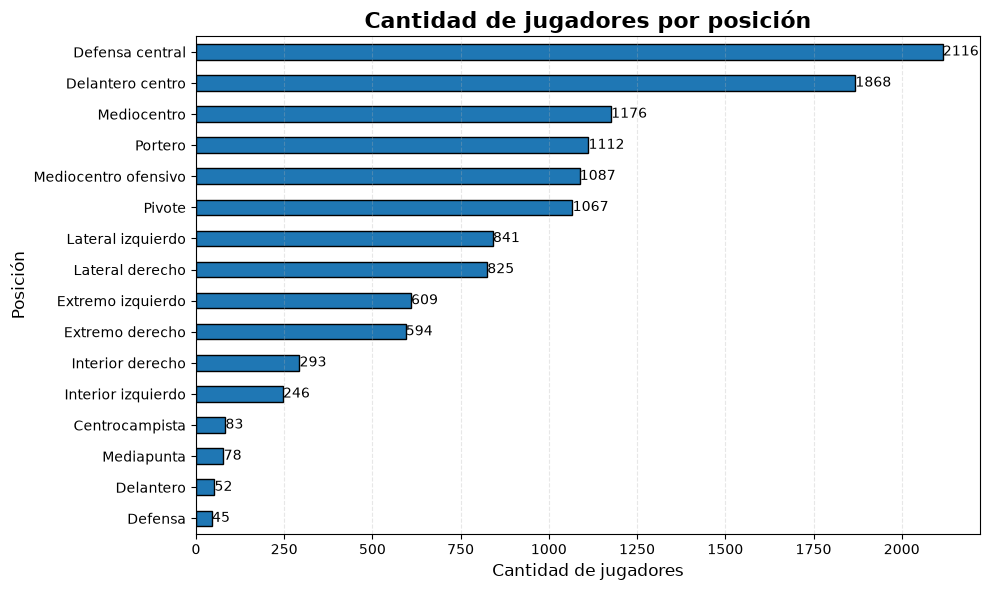

In [ ]:
posiciones = df["Posicion"].value_counts().sort_values()

plt.figure(figsize=(10, 6))

ax = posiciones.plot(
    kind="barh",
    edgecolor="black"
)

plt.title("Cantidad de jugadores por posición", fontsize=16, fontweight="bold")
plt.xlabel("Cantidad de jugadores", fontsize=12)
plt.ylabel("Posición", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.3)

for i, valor in enumerate(posiciones):
    ax.text(valor + 0.5, i, str(valor), va="center")

plt.tight_layout()
plt.show()

### Análisis e interpretación del gráfico

A simple vista, podemos observar que la posición con más jugadores en el dataset es la de **defensor central** (los clásicos "2" o "6"), seguida por los **delanteros centro** (los típicos "9"). Esto tiene lógica, ya que los planteles suelen tener mucho recambio y variantes para estos puestos clave.

Un detalle a tener en cuenta sobre la calidad de los datos es que el gráfico también muestra categorías muy generales (como "defensa" o "ataque"). Al ser etiquetas amplias que agrupan varias posiciones a la vez, no conviene compararlas directamente con los puestos individuales para no confundir la lectura.

Por otro lado, la posición con menor cantidad de jugadores es la de **mediapunta** (el tradicional enganche o "10"). Una posible explicación es la evolución de los esquemas tácticos en el fútbol moderno: el rol clásico del enganche fue perdiendo lugar y sus funciones hoy son asumidas por otros mediocampistas o extremos. De todas formas, vale aclarar que esta es una interpretación futbolística nuestra y no algo que se pueda comprobar matemáticamente solo mirando estos datos.

**Conclusión:**
El gráfico demuestra que la cantidad de jugadores registrados varía fuertemente según el puesto. Existe una clara superioridad numérica en los roles defensivos centrales, en contraste con una muy baja representación de posiciones creativas específicas como el mediapunta.

# Valor de mercado
Para poder analizar la variable **Valor de mercado**, primero fue necesario realizar una limpieza en los datos.
La columna original `Valor de mercado` era de tipo texto (*object*) porque contenía valores numéricos mezclados con guiones (`"-"`) para indicar datos no disponibles. Para poder graficarla correctamente sin inventar información:
1. Usamos `pd.to_numeric(df["Valor de mercado"], errors="coerce")` para convertir los números a formato numérico y transformar automáticamente los guiones `"-"` en valores nulos (`NaN`).
2. Creamos la variable `Valor_mercado_num` y le aplicamos `.dropna()` para trabajar únicamente con los registros que tienen un valor de mercado válido.

In [25]:
df["Valor_mercado_num"] = pd.to_numeric(
    df["Valor de mercado"],
    errors="coerce"
)

df["Valor_mercado_num"].dtype

dtype('float64')

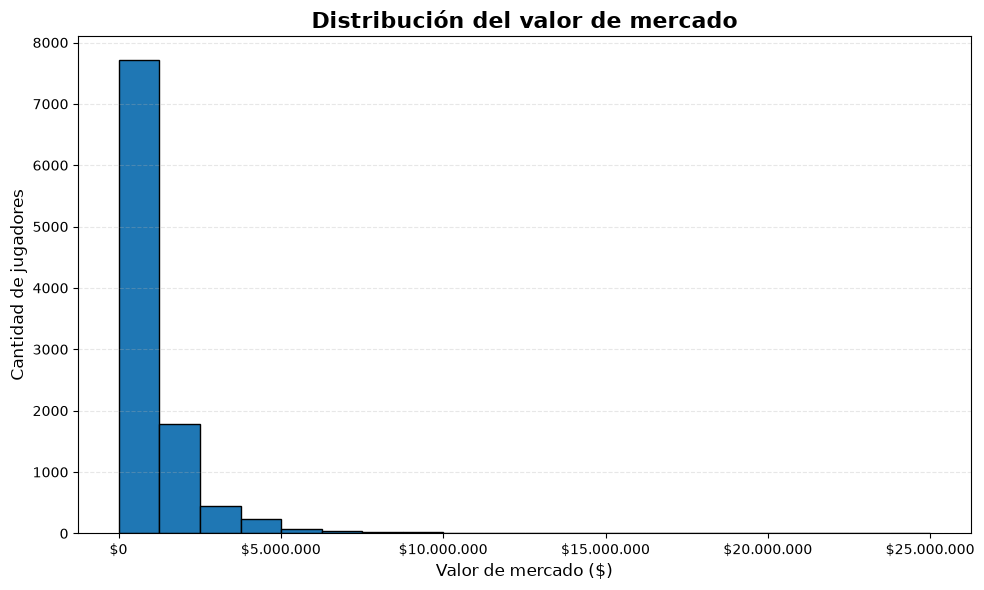

In [34]:
valores = df["Valor_mercado_num"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    valores,
    bins=20,
    edgecolor="black"
)

plt.title("Distribución del valor de mercado", fontsize=16, fontweight="bold")
plt.xlabel("Valor de mercado ($)", fontsize=12)
plt.ylabel("Cantidad de jugadores", fontsize=12)

plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(
        lambda x, pos: f"${x:,.0f}".replace(",", ".")
    )
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis e Interpretación del Histograma

El histograma muestra cómo se distribuye el valor de mercado de los jugadores presentes en el dataset. 

En el **eje horizontal (X)** se agrupan los valores de mercado en intervalos (rangos) de **$1.250.000**, mientras que en el **eje vertical (Y)** se indica la cantidad de jugadores pertenecientes a cada rango.

Analizando las primeras columnas antes de los **$5.000.000**, se observa lo siguiente:

* **Primera columna ($0 a $1.250.000):** Contiene a la gran mayoría de los futbolistas (casi 7.700 jugadores).
* **Segunda columna ($1.250.000 a $2.500.000):** Muestra una disminución drástica, agrupando a unos 1.800 jugadores.
* **Tercera columna ($2.500.000 a $3.750.000):** Agrupa a cerca de 450 jugadores.
* **Cuarta columna ($3.750.000 a $5.000.000):** Representa a aproximadamente 230 jugadores.

A partir de los **$5.000.000**, las barras son casi imperceptibles debido a que muy pocos jugadores alcanzan cifras tan altas dentro del fútbol argentino.

**Conclusión:**
El gráfico muestra una clara asimetría hacia la derecha (sesgo positivo). La enorme mayoría de los jugadores del fútbol argentino posee un valor de mercado accesible o relativamente bajo dentro del contexto del mercado general, mientras que solo un grupo muy reducido de futbolistas (casos atípicos o "estrellas" del torneo) alcanza cotizaciones millonarias.

# Proporción de jugadores según pie hábil
#### Tratamiento previo de la variable
Para esta visualización utilizamos la columna `Pie`. Al tratarse de una variable categórica con muy pocos valores únicos, no fue necesario realizar transformaciones complejas. Simplemente utilizamos el método `.value_counts()` para contar cuántos jugadores hay en cada categoría. Este método automáticamente ignora los valores nulos, por lo que no graficamos datos vacíos.

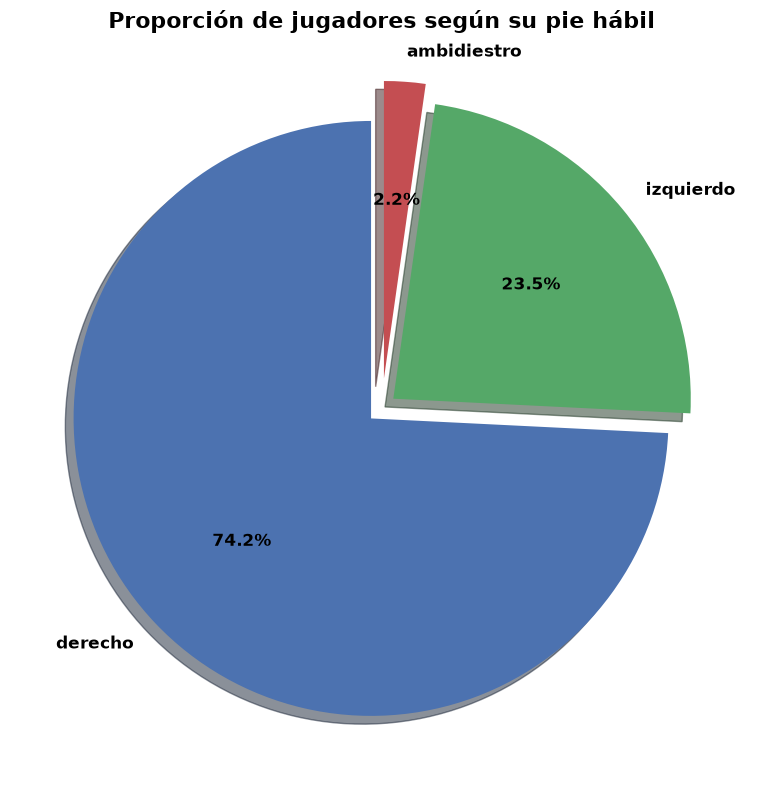

In [ ]:
pie_habil = df["Pie"].value_counts().head(3)

colores = ['#4C72B0', '#55A868', '#C44E52']
separacion = (0.05, 0.05, 0.1) if len(pie_habil) == 3 else (0.05, 0.05)

plt.figure(figsize=(8, 8))

plt.pie(
    pie_habil,
    labels=pie_habil.index,
    autopct='%1.1f%%', 
    startangle=90,     
    colors=colores[:len(pie_habil)],
    explode=separacion[:len(pie_habil)],
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

plt.title("Proporción de jugadores según su pie hábil", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

# Análisis e Interpretación del Gráfico

El gráfico de torta ilustra la distribución del pie dominante entre los futbolistas del dataset.

Cada porción del gráfico representa una categoría de pie hábil (por ejemplo, derecho, izquierdo, ambidiestro), y el tamaño de la porción es proporcional a la cantidad de jugadores que comparten esa característica respecto al total.

A simple vista, se puede confirmar una tendencia lógica dentro del fútbol y de la población en general:

*    La inmensa mayoría de los jugadores son diestros, abarcando la porción más grande del gráfico (más del 70% habitualmente).

*    Los jugadores zurdos representan la segunda minoría más importante.

*    Los jugadores ambidiestros (que manejan ambos perfiles con igual habilidad) son los más escasos, ocupando la porción más chica de la visualización.

**Conclusión:**
El gráfico cumple su función de mostrar proporciones de manera rápida e intuitiva. Nos permite confirmar que la distribución de la lateralidad en los futbolistas profesionales del dataset respeta la tendencia biológica habitual, con una clara predominancia del perfil diestro.

# Conclusión Final del Análisis

Como conclusión general de este Trabajo Práctico, el análisis del dataset `futbolargentino` nos permitió entender de manera práctica cómo se estructuran los planteles del fútbol nacional y, al mismo tiempo, enfrentarnos a los desafíos reales que implica trabajar con datos crudos.